# Set-UP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Introduction


The **Household Consumption Expenditure Survey (HCES) 2023–24**, conducted by the Ministry of Statistics and Programme Implementation (MoSPI), provides comprehensive insights into the spending patterns and living standards of households across India.

This project aims to analyze and compare **rural and urban consumption behavior** using multiple HCES datasets, including:

* Monthly Per Capita Expenditure (MPCE)
* Category-wise consumption (food, education, health, etc.)
* Percentage distribution of expenditure

The primary objective is to understand:

* The **economic gap** between rural and urban households
* Differences in **spending priorities and lifestyle patterns**
* How expenditure distribution reflects **development and standard of living**

By leveraging data analysis and visualization techniques, this project transforms raw survey data into meaningful insights that can help interpret **socio-economic disparities in India**.

---
## Tools & Technologies Used

* Python (Pandas, NumPy)
* Data Visualization (Matplotlib, Seaborn)
* Jupyter Notebook
* strimlit for dashboard

---

## Dataset Source

* Household Consumption Expenditure Survey (HCES) 2023–24
* Ministry of Statistics and Programme Implementation (MoSPI), Government of India


# Loading Data 

In [2]:
df_mpce = pd.read_csv("../dataset/1.csv")

In [3]:
df_consumption_rural = pd.read_csv("../dataset/3R.csv")

In [4]:
df_consumption_urban = pd.read_csv("../dataset/3U.csv")

In [5]:
df_percent_rural = pd.read_csv("../dataset/4R.csv")

In [6]:
df_percent_urban = pd.read_csv("../dataset/4U.csv")

## Monthly Per Capita Expenditure (Rural vs Urban) - Statement 1

In [7]:
print("Monthly Per Capita Expenditure (Rural vs Urban)")
df_mpce.head()

Monthly Per Capita Expenditure (Rural vs Urban)


,State/UT,Average MPCE - Rural,Average MPCE - Urban,Average MPCE With Imputation - Rural,Average MPCE With Imputation - Urban
0,Andhra Pradesh,"5,327","7,182","5,539","7,341"
1,Arunachal Pradesh,"5,995","9,832","6,107","9,877"
2,Assam,"3,793","6,794","3,961","6,913"
3,Bihar,"3,670","5,080","3,788","5,165"
4,Chhattisgarh,"2,739","4,927","2,927","5,114"


In [8]:
df_mpce.columns

Index(['State/UT', 'Average MPCE - Rural', 'Average MPCE - Urban',
       'Average MPCE With Imputation - Rural',
       'Average MPCE With Imputation - Urban'],
      dtype='object')

In [9]:
df_mpce.shape

(37, 5)

In [10]:
df_mpce = df_mpce.rename(columns={
    'State/UT': 'state',
    'Average MPCE - Rural': 'rural',
    'Average MPCE - Urban': 'urban'})
df_mpce = df_mpce[['state', 'rural', 'urban']]

In [11]:
df_mpce.head()

,state,rural,urban
0,Andhra Pradesh,"5,327","7,182"
1,Arunachal Pradesh,"5,995","9,832"
2,Assam,"3,793","6,794"
3,Bihar,"3,670","5,080"
4,Chhattisgarh,"2,739","4,927"


In [38]:
df_mpce.describe()

,state,rural,urban
count,37,37,37
unique,37,37,37
top,Andhra Pradesh,"5,327","7,182"
freq,1,1,1


## Rural spending (₹ values by category) - Statement 3R

In [12]:
print("Rural spending (₹ values by category)")
df_consumption_rural.head()

Rural spending (₹ values by category)


,State/UT,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total,vertical
0,Andhra Pradesh,270.32,0.11,6.35,107.90,24.53,5.10,367.10,253.13,150.30,...,258.40,87.62,39.62,34.52,232.15,36.13,403.12,2894.46,5336.73,NaN
1,Arunachal Pradesh,364.45,0.02,7.64,45.36,16.46,4.60,224.60,443.83,171.35,...,232.14,32.28,32.17,14.52,553.22,62.20,633.35,3182.82,5994.74,NaN
2,Assam,304.44,NaN,5.46,57.23,19.33,4.54,221.83,298.23,124.92,...,169.27,22.00,8.07,6.85,231.04,30.41,119.33,1774.42,4293.27,NaN
3,Bihar,311.83,0.01,12.22,65.65,25.14,4.75,535.46,255.72,127.12,...,133.94,31.01,14.83,7.84,NaN,27.60,273.97,1731.52,3661.33,207.32
4,Chhattisgarh,225.33,0.01,10.41,85.25,23.91,3.59,90.24,253.61,72.49,...,118.50,20.09,7.31,10.54,154.65,28.07,137.36,1451.41,2728.61,NaN


In [13]:
df_consumption_rural.shape

(37, 34)

In [14]:
df_consumption_rural.columns

Index(['State/UT', 'cereal', 'cereal_substitutes', 'gram', 'pulses', 'sugar',
       'salt', 'milk', 'vegetables', 'fruits_fresh', 'fruits_dry', 'egg_meat',
       'edible_oil', 'spices', 'beverages', 'food_total', 'tobacco', 'fuel',
       'toilet', 'household', 'education', 'medical_hosp', 'medical_non',
       'conveyance', 'services', 'entertainment', 'rent', 'taxes', 'clothing',
       'footwear', 'durable', 'nonfood_total', 'total', 'vertical'],
      dtype='object')

In [15]:
df_consumption_rural = df_consumption_rural.drop(columns=['vertical'], errors='ignore')

In [16]:
df_consumption_rural.columns = df_consumption_rural.columns.str.strip().str.lower()

In [17]:
df_consumption_rural[:5]

,state/ut,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
0,Andhra Pradesh,270.32,0.11,6.35,107.90,24.53,5.10,367.10,253.13,150.30,...,471.29,258.40,87.62,39.62,34.52,232.15,36.13,403.12,2894.46,5336.73
1,Arunachal Pradesh,364.45,0.02,7.64,45.36,16.46,4.60,224.60,443.83,171.35,...,447.13,232.14,32.28,32.17,14.52,553.22,62.20,633.35,3182.82,5994.74
2,Assam,304.44,NaN,5.46,57.23,19.33,4.54,221.83,298.23,124.92,...,225.05,169.27,22.00,8.07,6.85,231.04,30.41,119.33,1774.42,4293.27
3,Bihar,311.83,0.01,12.22,65.65,25.14,4.75,535.46,255.72,127.12,...,178.10,133.94,31.01,14.83,7.84,NaN,27.60,273.97,1731.52,3661.33
4,Chhattisgarh,225.33,0.01,10.41,85.25,23.91,3.59,90.24,253.61,72.49,...,213.65,118.50,20.09,7.31,10.54,154.65,28.07,137.36,1451.41,2728.61


In [37]:
df_consumption_rural.describe()

,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,fruits_dry,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
count,37.000000,25.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,36.000000,37.000000,37.000000,37.000000,36.000000,37.000000,37.000000,37.000000,37.000000
mean,263.547027,1.315200,11.491622,78.402432,30.724324,4.282162,411.844324,309.222973,143.806486,59.646216,...,393.162162,252.182500,63.650000,56.648378,11.286486,325.463889,56.524865,379.423514,2842.262162,5300.459730
std,47.334507,2.584912,7.300087,28.472798,12.145298,0.874561,262.868785,101.196430,55.890426,31.432389,...,246.790525,101.149659,47.202579,91.145653,9.787299,130.852543,31.599002,183.401510,999.060935,1688.923594
min,127.320000,0.010000,0.940000,23.950000,13.700000,2.840000,90.240000,136.530000,62.340000,22.250000,...,121.270000,114.220000,10.950000,2.890000,0.200000,154.650000,27.600000,117.640000,1451.410000,2728.610000
25%,225.330000,0.030000,6.850000,53.310000,21.430000,3.730000,224.600000,252.390000,105.880000,37.080000,...,225.050000,187.780000,32.280000,11.220000,5.080000,231.175000,36.130000,242.430000,2098.390000,4145.340000
50%,265.340000,0.520000,10.110000,81.330000,30.660000,4.140000,333.190000,276.590000,127.120000,49.320000,...,330.120000,237.290000,42.750000,19.420000,7.840000,279.620000,42.130000,348.490000,2692.940000,5154.700000
75%,298.660000,1.250000,14.940000,97.060000,39.750000,4.600000,546.540000,352.360000,170.550000,81.420000,...,407.300000,311.470000,87.620000,42.760000,14.520000,388.372500,63.770000,522.310000,3349.050000,6235.150000
max,364.450000,12.550000,30.430000,143.190000,62.340000,7.220000,1112.090000,605.640000,304.360000,135.230000,...,1281.790000,501.450000,215.310000,444.100000,43.530000,753.010000,155.360000,770.700000,5241.380000,9377.190000


## Urban spending (₹ values by category) - Statement 3U

In [18]:
print("Urban spending (₹ values by category)")
df_consumption_urban.head()

Urban spending (₹ values by category)


,State/UT,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
0,Andhra Pradesh,285.01,0.01,7.31,110.79,24.56,5.13,430.80,278.90,217.57,...,605.01,343.84,143.13,577.30,24.41,315.40,48.10,536.20,4349.81,7181.54
1,Arunachal Pradesh,348.72,0.09,13.04,74.56,23.02,5.17,377.16,510.66,302.53,...,784.44,512.73,162.91,697.83,28.53,458.00,79.45,668.24,5481.06,9832.05
2,Assam,292.47,NaN,7.76,73.38,24.38,5.45,303.03,356.27,195.23,...,508.17,345.25,113.61,321.69,21.47,358.81,46.15,367.06,3574.13,6794.31
3,Bihar,292.84,0.00,14.63,76.04,28.16,5.32,487.41,284.53,140.39,...,283.22,223.88,77.18,158.04,11.22,264.86,36.39,316.44,2601.50,5080.37
4,Chhattisgarh,219.93,0.31,15.82,112.83,30.16,4.25,271.93,342.67,136.33,...,445.10,274.02,79.04,158.37,43.98,287.18,44.80,263.55,2930.23,4927.33


In [19]:
df_consumption_urban.shape

(37, 33)

In [20]:
df_consumption_urban.columns

Index(['State/UT', 'cereal', 'cereal_substitutes', 'gram', 'pulses', 'sugar',
       'salt', 'milk', 'vegetables', 'fruits_fresh', 'fruits_dry', 'egg_meat',
       'edible_oil', 'spices', 'beverages', 'food_total', 'tobacco', 'fuel',
       'toilet', 'household', 'education', 'medical_hosp', 'medical_non',
       'conveyance', 'services', 'entertainment', 'rent', 'taxes', 'clothing',
       'footwear', 'durable', 'nonfood_total', 'total'],
      dtype='object')

In [21]:
df_consumption_urban.columns = df_consumption_urban.columns.str.strip().str.lower()

In [22]:
df_consumption_urban.head()

,state/ut,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
0,Andhra Pradesh,285.01,0.01,7.31,110.79,24.56,5.13,430.80,278.90,217.57,...,605.01,343.84,143.13,577.30,24.41,315.40,48.10,536.20,4349.81,7181.54
1,Arunachal Pradesh,348.72,0.09,13.04,74.56,23.02,5.17,377.16,510.66,302.53,...,784.44,512.73,162.91,697.83,28.53,458.00,79.45,668.24,5481.06,9832.05
2,Assam,292.47,NaN,7.76,73.38,24.38,5.45,303.03,356.27,195.23,...,508.17,345.25,113.61,321.69,21.47,358.81,46.15,367.06,3574.13,6794.31
3,Bihar,292.84,0.00,14.63,76.04,28.16,5.32,487.41,284.53,140.39,...,283.22,223.88,77.18,158.04,11.22,264.86,36.39,316.44,2601.50,5080.37
4,Chhattisgarh,219.93,0.31,15.82,112.83,30.16,4.25,271.93,342.67,136.33,...,445.10,274.02,79.04,158.37,43.98,287.18,44.80,263.55,2930.23,4927.33


In [36]:
df_consumption_urban.describe()

,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,fruits_dry,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
count,37.000000,26.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000
mean,276.015135,1.010769,13.501081,86.970000,33.833243,5.178108,515.700541,355.048378,215.437027,97.264595,...,615.988919,434.936216,124.433514,469.387027,18.718649,400.840811,82.102432,530.655946,4484.093784,7720.833243
std,52.742996,1.750906,7.417858,27.320229,11.383172,0.968684,280.250236,108.706909,70.550896,48.418804,...,189.427749,186.628452,42.290543,297.268819,12.191802,134.608919,47.013044,206.761523,1223.101531,1995.831455
min,168.150000,0.000000,0.900000,34.590000,16.810000,3.080000,135.940000,235.180000,123.490000,41.450000,...,283.220000,223.880000,49.430000,45.470000,0.430000,255.890000,36.390000,263.550000,2601.500000,4927.330000
25%,231.800000,0.012500,7.760000,74.320000,24.380000,4.590000,303.030000,284.530000,160.390000,76.100000,...,487.760000,316.340000,93.690000,232.960000,9.740000,319.820000,54.970000,372.200000,3567.980000,6376.800000
50%,285.010000,0.295000,13.090000,85.290000,31.290000,5.070000,436.970000,323.140000,211.760000,86.520000,...,605.010000,403.080000,115.920000,401.410000,16.540000,358.720000,62.560000,480.940000,4375.240000,7485.810000
75%,292.840000,1.197500,17.470000,104.690000,42.450000,5.610000,660.020000,399.810000,276.810000,104.960000,...,683.520000,523.980000,143.480000,640.570000,22.570000,436.950000,81.720000,608.380000,5063.680000,8534.460000
max,397.010000,8.140000,31.510000,180.720000,57.300000,8.080000,1272.860000,682.370000,393.400000,325.100000,...,1237.630000,1272.750000,271.170000,1344.850000,54.640000,908.040000,221.800000,1094.660000,8423.660000,13926.750000


## Rural percentage distribution - Statement 4R

In [23]:
print("Rural percentage distribution")
df_percent_rural.head()

Rural percentage distribution


,State/UT,cereal,cereal substitutes,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
0,Andhra Pradesh,4.70,0,0.13,2.03,0.46,0.10,6.80,5.32,3.41,...,8.94,4.77,1.83,0.74,0.28,4.73,0.68,6.74,54.15,100
1,Arunachal Pradesh,4.36,0,0.13,0.83,0.27,0.08,3.41,7.50,2.86,...,7.46,4.54,1.46,0.87,0.24,5.89,1.04,6.74,49.76,100
2,Assam,5.39,-,0.14,1.51,0.51,0.11,4.53,7.90,3.29,...,5.95,4.46,1.00,0.23,0.18,6.20,0.85,4.74,46.78,100
3,Bihar,6.59,0,0.33,1.87,0.69,0.13,9.08,6.91,2.92,...,4.86,5.01,0.89,0.38,0.21,5.65,0.75,5.71,47.47,100
4,Chhattis-garh,3.87,0,0.38,3.22,0.80,0.05,3.37,10.43,2.65,...,8.05,4.69,0.73,0.27,0.40,6.74,1.05,5.04,53.37,100


In [24]:
df_percent_rural.shape

(37, 33)

In [25]:
df_percent_rural.columns

Index(['State/UT', 'cereal', 'cereal substitutes', 'gram',
       'pulses and pulse products*', 'sugar', 'salt', 'milk and milk products',
       'vegetables', 'fruits (fresh)', 'fruits (dry)', 'egg, fish & meat',
       'edible oil', 'spices', 'beverages, processed food#, etc.',
       'food: total (1-14) ', 'pan, tobacco & intoxicants', 'fuel and light',
       'toilet articles', 'other household consumables', 'education',
       'medical (hospitalization)', 'medical (non- hospitalization)',
       'conveyance', 'consumer services excluding conveyance&',
       'entertainment', 'rent', 'other taxes & cesses', 'clothing & bedding$',
       'footwear', 'durable goods', 'non-food: total (16-30)',
       'total expenditure (15+31)'],
      dtype='object')

In [35]:
df_percent_rural.describe()

,cereal,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),fruits (dry),"egg, fish & meat",...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
count,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.0
mean,4.503784,0.225676,1.561081,0.642162,0.093243,7.328649,6.082432,2.796486,1.151892,6.341081,...,7.615676,5.134595,1.142162,1.114865,0.201892,5.758649,1.118649,6.584324,52.988649,100.0
std,1.371077,0.120843,0.602208,0.250390,0.030917,4.245283,1.602364,0.621388,0.440100,3.690471,...,1.799870,0.595971,0.422881,1.485298,0.138561,1.031049,0.463196,1.591192,3.743400,0.0
min,2.140000,0.010000,0.700000,0.260000,0.050000,2.020000,3.100000,1.900000,0.450000,0.920000,...,4.220000,3.720000,0.440000,0.060000,0.000000,3.990000,0.640000,3.960000,42.730000,100.0
25%,3.750000,0.130000,1.020000,0.430000,0.070000,3.830000,4.880000,2.370000,0.820000,3.040000,...,6.420000,4.710000,0.790000,0.260000,0.110000,4.930000,0.820000,5.470000,51.130000,100.0
50%,4.410000,0.240000,1.550000,0.630000,0.090000,5.680000,6.030000,2.680000,1.090000,6.230000,...,7.460000,5.250000,1.020000,0.560000,0.180000,5.670000,1.000000,6.490000,53.030000,100.0
75%,5.020000,0.330000,1.880000,0.800000,0.110000,10.930000,6.910000,3.140000,1.380000,9.720000,...,8.680000,5.450000,1.450000,1.350000,0.240000,6.370000,1.260000,7.160000,55.480000,100.0
max,7.900000,0.430000,3.220000,1.110000,0.150000,20.640000,10.430000,4.690000,2.380000,13.720000,...,11.480000,6.320000,2.140000,7.880000,0.650000,8.470000,3.080000,10.540000,59.680000,100.0


## Urban percentage distribution - Statement 4U

In [26]:
print("Urban percentage distribution")
df_percent_urban.head()

Urban percentage distribution


,State,cereal,cereal substitutes,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
0,Andhra Pradesh,3.97,0.00,0.10,1.54,0.34,0.07,6.00,3.88,3.03,...,8.42,4.79,1.99,8.04,0.34,4.39,0.67,7.47,60.57,100
1,Arunachal Pradesh,3.55,0.00,0.13,0.76,0.23,0.05,3.84,5.19,3.08,...,7.98,5.21,1.66,7.10,0.29,4.66,0.81,6.80,55.75,100
2,Assam,4.30,NaN,0.11,1.08,0.36,0.08,4.46,5.24,2.87,...,7.48,5.08,1.67,4.73,0.32,5.28,0.68,5.40,52.60,100
3,Bihar,5.76,0.00,0.29,1.50,0.55,0.10,9.59,5.60,2.76,...,5.57,4.41,1.52,3.11,0.22,5.21,0.72,6.23,51.21,100
4,Chhattis-garh,4.47,0.01,0.32,2.29,0.61,0.09,5.52,6.95,2.77,...,9.03,5.56,1.60,3.21,0.89,5.83,0.91,5.35,59.47,100


In [27]:
df_percent_urban.shape

(37, 33)

In [28]:
df_percent_urban.columns

Index(['State', 'cereal', 'cereal substitutes', 'gram',
       'pulses and pulse products*', 'sugar', 'salt', 'milk and milk products',
       'vegetables', 'fruits (fresh)', 'fruits (dry)', 'egg, fish & meat',
       'edible oil', 'spices', 'beverages, processed food#, etc.',
       'food: total (1-14) ', 'pan, tobacco & intoxicants', 'fuel and light',
       'toilet articles', 'other household consumables', 'education',
       'medical (hospitalization)', 'medical (non- hospitalization)',
       'conveyance', 'consumer services excluding conveyance&',
       'entertainment', 'rent', 'other taxes & cesses', 'clothing & bedding$',
       'footwear', 'durable goods', 'non-food: total (16-30)',
       'total expenditure (15+31)'],
      dtype='object')

In [34]:
df_percent_urban.describe()

,cereal,cereal substitutes,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),fruits (dry),...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
count,37.000000,26.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,...,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.000000,37.0
mean,3.740811,0.013846,0.180270,1.170270,0.452973,0.070811,6.697027,4.665946,2.790811,1.253514,...,8.021622,5.515946,1.608108,5.740000,0.254595,5.194324,1.032703,6.791622,57.989459,100.0
std,1.026908,0.023508,0.092421,0.399287,0.162273,0.019491,3.146900,1.034737,0.619737,0.400557,...,1.604803,1.062956,0.320051,2.722776,0.182507,0.886662,0.402151,1.623368,4.328946,0.0
min,1.930000,0.000000,0.010000,0.500000,0.220000,0.030000,2.130000,3.020000,1.820000,0.610000,...,4.480000,3.620000,0.780000,0.760000,0.010000,3.900000,0.620000,4.150000,45.900000,100.0
25%,2.970000,0.000000,0.110000,0.880000,0.340000,0.060000,4.200000,3.880000,2.370000,1.010000,...,6.850000,4.900000,1.440000,3.240000,0.130000,4.530000,0.750000,5.710000,55.840000,100.0
50%,3.680000,0.005000,0.170000,1.160000,0.430000,0.070000,5.800000,4.560000,2.680000,1.260000,...,8.180000,5.330000,1.660000,5.580000,0.230000,5.210000,0.910000,6.580000,58.760000,100.0
75%,3.970000,0.017500,0.260000,1.420000,0.550000,0.080000,9.200000,5.320000,2.870000,1.460000,...,9.030000,6.070000,1.820000,8.040000,0.320000,5.680000,1.140000,7.380000,61.430000,100.0
max,6.680000,0.100000,0.320000,2.290000,0.900000,0.110000,13.990000,6.950000,4.930000,2.420000,...,11.090000,9.480000,2.220000,11.980000,0.890000,7.610000,2.470000,11.400000,63.860000,100.0


# Analyzing

## Rural vs Urban Income Gap

> In this section we going to work with the income data

In [39]:
df_mpce[:5]

,state,rural,urban
0,Andhra Pradesh,"5,327","7,182"
1,Arunachal Pradesh,"5,995","9,832"
2,Assam,"3,793","6,794"
3,Bihar,"3,670","5,080"
4,Chhattisgarh,"2,739","4,927"


In [40]:
# Remove commas and convert to numeric
df_mpce['rural'] = df_mpce['rural'].astype(str).str.replace(',', '').astype(float)
df_mpce['urban'] = df_mpce['urban'].astype(str).str.replace(',', '').astype(float)
df_mpce.head()

,state,rural,urban
0,Andhra Pradesh,5327.0,7182.0
1,Arunachal Pradesh,5995.0,9832.0
2,Assam,3793.0,6794.0
3,Bihar,3670.0,5080.0
4,Chhattisgarh,2739.0,4927.0


- The MPCE values were stored as strings with commas, which prevents numerical operations.
- We cleaned the data by removing commas and converting the values into numeric format(float).

In [41]:
# Create new column
df_mpce['gap'] = df_mpce['urban'] - df_mpce['rural']
df_mpce.head()

,state,rural,urban,gap
0,Andhra Pradesh,5327.0,7182.0,1855.0
1,Arunachal Pradesh,5995.0,9832.0,3837.0
2,Assam,3793.0,6794.0,3001.0
3,Bihar,3670.0,5080.0,1410.0
4,Chhattisgarh,2739.0,4927.0,2188.0


- A new feature gap is created to measure the difference in urban and rural expenditure.
- This helps quantify the economic disparity across regions.

---

In [42]:
# lets look at the basic statics
df_mpce.describe()

,rural,urban,gap
count,37.000000,37.000000,37.000000
mean,5275.405405,7720.837838,2445.432432
std,1645.058146,1995.919149,986.895653
min,2739.000000,4927.000000,27.000000
25%,4116.000000,6377.000000,1775.000000
50%,5010.000000,7486.000000,2468.000000
75%,5995.000000,8534.000000,3050.000000
max,9377.000000,13927.000000,4568.000000


---

In [43]:
# Top 10 states with highest gap
top_gap = df_mpce.sort_values(by='gap', ascending=False).head(10)
# Bottom 10 states with lowest gap
bottom_gap = df_mpce.sort_values(by='gap').head(10)

In [45]:
top_gap

,state,rural,urban,gap
30,Chandigarh,8857.0,13425.0,4568.0
22,Sikkim,9377.0,13927.0,4550.0
16,Meghalaya,3852.0,7839.0,3987.0
1,Arunachal Pradesh,5995.0,9832.0,3837.0
24,Telangana,5435.0,8978.0,3543.0
9,Himachal Pradesh,5825.0,9223.0,3398.0
14,Maharashtra,4145.0,7363.0,3218.0
11,Karnataka,4903.0,8076.0,3173.0
7,Gujarat,4116.0,7175.0,3059.0
8,Haryana,5377.0,8427.0,3050.0


In [47]:
bottom_gap

,state,rural,urban,gap
34,Lakshadweep,6350.0,6377.0,27.0
35,Puducherry,7598.0,8637.0,1039.0
5,Delhi,7400.0,8534.0,1134.0
12,Kerala,6611.0,7783.0,1172.0
3,Bihar,3670.0,5080.0,1410.0
15,Manipur,4531.0,5945.0,1414.0
20,Punjab,5817.0,7359.0,1542.0
32,Jammu & Kashmir,4774.0,6327.0,1553.0
6,Goa,8048.0,9726.0,1678.0
25,Tripura,6259.0,8034.0,1775.0


---

### Visualization

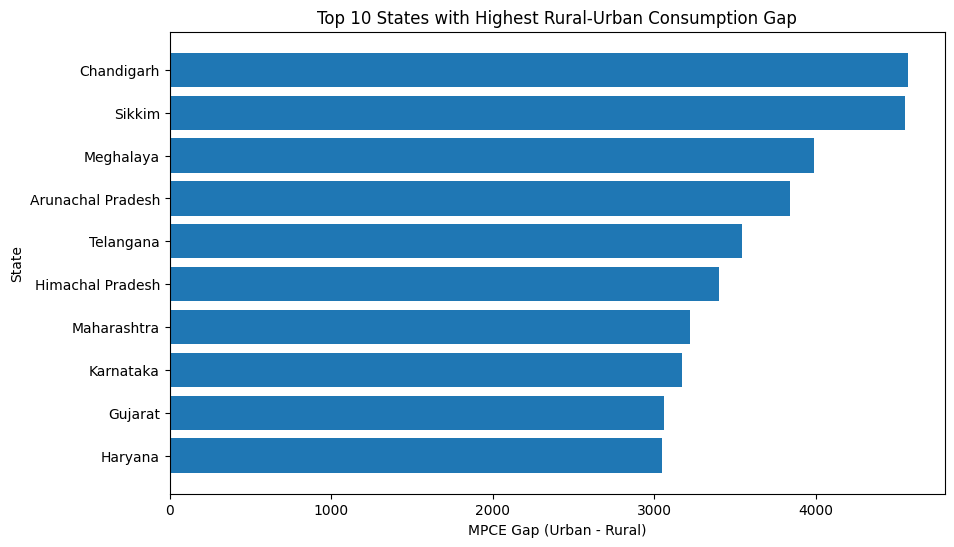

In [48]:
# Top 10 gap visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top_gap['state'], top_gap['gap'])
plt.xlabel("MPCE Gap (Urban - Rural)")
plt.ylabel("State")
plt.title("Top 10 States with Highest Rural-Urban Consumption Gap")
plt.gca().invert_yaxis()
plt.show()

The visualization highlights regions where urban households significantly outspend rural households, indicating economic concentration and possible inequality in access to resources.

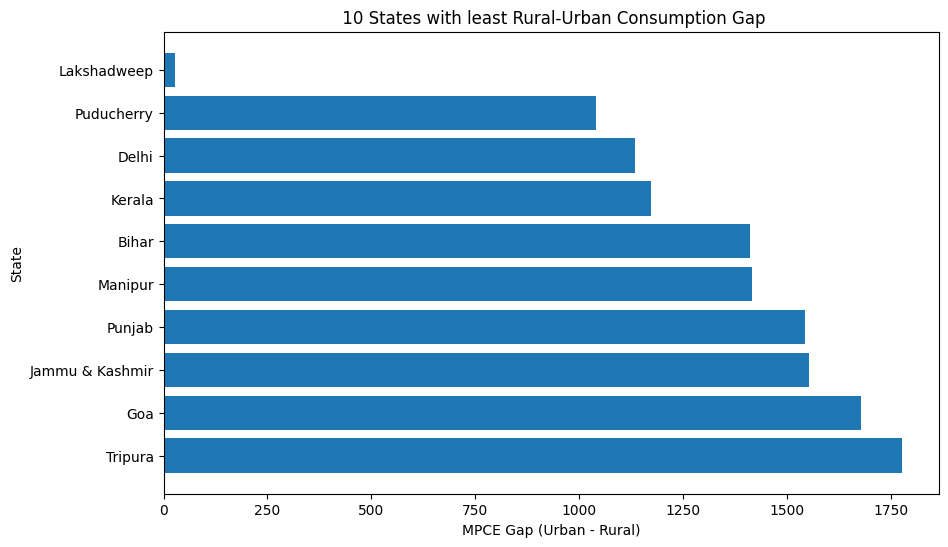

In [49]:
# bottom 10 gap visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(bottom_gap['state'], bottom_gap['gap'])
plt.xlabel("MPCE Gap (Urban - Rural)")
plt.ylabel("State")
plt.title(" 10 States with least Rural-Urban Consumption Gap")
plt.gca().invert_yaxis()
plt.show()

---

In [50]:
df_mpce[df_mpce['state'] == 'All-India']

,state,rural,urban,gap
36,All-India,4122.0,6996.0,2874.0


At the national level, urban MPCE is substantially higher than rural MPCE, confirming a widespread consumption gap across India

## Spending behavior (food vs non-food)

- we are Using:
    - df_consumption_rural
    - df_consumption_urban
- We will answer:
>Do rural and urban households spend differently on:
1. Food
2. Education
3. Healthcare
4. Services

---

In [52]:
df_consumption_rural[:5]

,state/ut,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
0,Andhra Pradesh,270.32,0.11,6.35,107.90,24.53,5.10,367.10,253.13,150.30,...,471.29,258.40,87.62,39.62,34.52,232.15,36.13,403.12,2894.46,5336.73
1,Arunachal Pradesh,364.45,0.02,7.64,45.36,16.46,4.60,224.60,443.83,171.35,...,447.13,232.14,32.28,32.17,14.52,553.22,62.20,633.35,3182.82,5994.74
2,Assam,304.44,NaN,5.46,57.23,19.33,4.54,221.83,298.23,124.92,...,225.05,169.27,22.00,8.07,6.85,231.04,30.41,119.33,1774.42,4293.27
3,Bihar,311.83,0.01,12.22,65.65,25.14,4.75,535.46,255.72,127.12,...,178.10,133.94,31.01,14.83,7.84,NaN,27.60,273.97,1731.52,3661.33
4,Chhattisgarh,225.33,0.01,10.41,85.25,23.91,3.59,90.24,253.61,72.49,...,213.65,118.50,20.09,7.31,10.54,154.65,28.07,137.36,1451.41,2728.61


In [53]:
df_consumption_urban[:5]

,state/ut,cereal,cereal_substitutes,gram,pulses,sugar,salt,milk,vegetables,fruits_fresh,...,conveyance,services,entertainment,rent,taxes,clothing,footwear,durable,nonfood_total,total
0,Andhra Pradesh,285.01,0.01,7.31,110.79,24.56,5.13,430.80,278.90,217.57,...,605.01,343.84,143.13,577.30,24.41,315.40,48.10,536.20,4349.81,7181.54
1,Arunachal Pradesh,348.72,0.09,13.04,74.56,23.02,5.17,377.16,510.66,302.53,...,784.44,512.73,162.91,697.83,28.53,458.00,79.45,668.24,5481.06,9832.05
2,Assam,292.47,NaN,7.76,73.38,24.38,5.45,303.03,356.27,195.23,...,508.17,345.25,113.61,321.69,21.47,358.81,46.15,367.06,3574.13,6794.31
3,Bihar,292.84,0.00,14.63,76.04,28.16,5.32,487.41,284.53,140.39,...,283.22,223.88,77.18,158.04,11.22,264.86,36.39,316.44,2601.50,5080.37
4,Chhattisgarh,219.93,0.31,15.82,112.83,30.16,4.25,271.93,342.67,136.33,...,445.10,274.02,79.04,158.37,43.98,287.18,44.80,263.55,2930.23,4927.33


---

The dataset contains many categories, but only the most relevant ones are selected to simplify analysis and focus on key spending areas such as food, education, healthcare, and services.

In [54]:
important_cols = ['state/ut','food_total','nonfood_total','education','medical_hosp','medical_non','conveyance','services']
df_rural = df_consumption_rural[important_cols].copy()
df_urban = df_consumption_urban[important_cols].copy()

In [55]:
df_rural[:5]

,state/ut,food_total,nonfood_total,education,medical_hosp,medical_non,conveyance,services
0,Andhra Pradesh,2442.27,2894.46,150.66,128.77,507.77,471.29,258.40
1,Arunachal Pradesh,2811.92,3182.82,124.10,32.00,161.40,447.13,232.14
2,Assam,2518.83,1774.42,110.10,50.44,102.80,225.05,169.27
3,Bihar,1929.81,1731.52,117.84,46.33,179.85,178.10,133.94
4,Chhattisgarh,1277.20,1451.41,55.05,31.37,112.41,213.65,118.50


In [56]:
df_urban[:5]

,state/ut,food_total,nonfood_total,education,medical_hosp,medical_non,conveyance,services
0,Andhra Pradesh,2831.72,4349.81,402.77,117.24,335.38,605.01,343.84
1,Arunachal Pradesh,4350.99,5481.06,319.51,60.91,294.87,784.44,512.73
2,Assam,3220.17,3574.13,217.45,72.24,205.71,508.17,345.25
3,Bihar,2478.87,2601.50,271.07,73.32,228.47,283.22,223.88
4,Chhattisgarh,1997.10,2930.23,218.22,57.79,229.65,445.10,274.02


---

In [57]:
df_rural['health_total'] = df_rural['medical_hosp'] + df_rural['medical_non']
df_urban['health_total'] = df_urban['medical_hosp'] + df_urban['medical_non']

- Healthcare expenditure is split into hospitalization and non-hospitalization.
- These are combined to get a clearer picture of total healthcare spending.

In [59]:
rural_india = df_rural[df_rural['state/ut'] == 'All-India']
urban_india = df_urban[df_urban['state/ut'] == 'All-India']

In [60]:
rural_india

,state/ut,food_total,nonfood_total,education,medical_hosp,medical_non,conveyance,services,health_total
36,All-India,1908.5,2113.83,123.42,88.33,185.73,218.37,214.57,274.06


In [61]:
urban_india

,state/ut,food_total,nonfood_total,education,medical_hosp,medical_non,conveyance,services,health_total
36,All-India,2776.46,4219.79,417.58,137.01,272.35,592.05,400.07,409.36


The All-India row provides an overall comparison of spending patterns between rural and urban households

---

lets create a **"comparison"** table for better insights at one place of both urban and rural.

In [63]:
comparison = pd.DataFrame({
    'Category': ['Food', 'Non-Food', 'Education', 'Health', 'Conveyance', 'Services'],
    'Rural': [
        rural_india['food_total'].values[0],
        rural_india['nonfood_total'].values[0],
        rural_india['education'].values[0],
        rural_india['health_total'].values[0],
        rural_india['conveyance'].values[0],
        rural_india['services'].values[0]
    ],
    'Urban': [
        urban_india['food_total'].values[0],
        urban_india['nonfood_total'].values[0],
        urban_india['education'].values[0],
        urban_india['health_total'].values[0],
        urban_india['conveyance'].values[0],
        urban_india['services'].values[0]
    ]
})
comparison

,Category,Rural,Urban
0,Food,1908.50,2776.46
1,Non-Food,2113.83,4219.79
2,Education,123.42,417.58
3,Health,274.06,409.36
4,Conveyance,218.37,592.05
5,Services,214.57,400.07


### Visualization

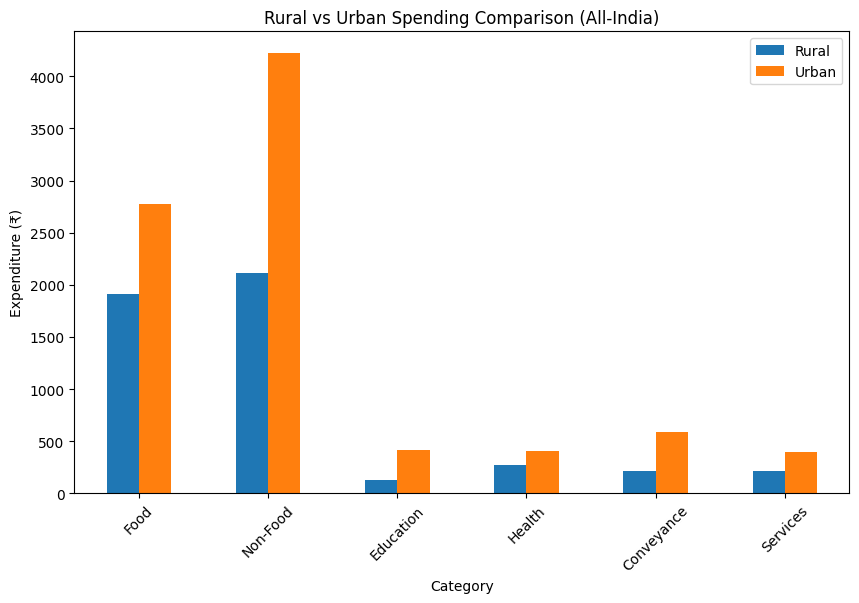

In [64]:
import matplotlib.pyplot as plt
comparison.set_index('Category').plot(kind='bar', figsize=(10,6))
plt.title("Rural vs Urban Spending Comparison (All-India)")
plt.ylabel("Expenditure (₹)")
plt.xticks(rotation=45)
plt.show()

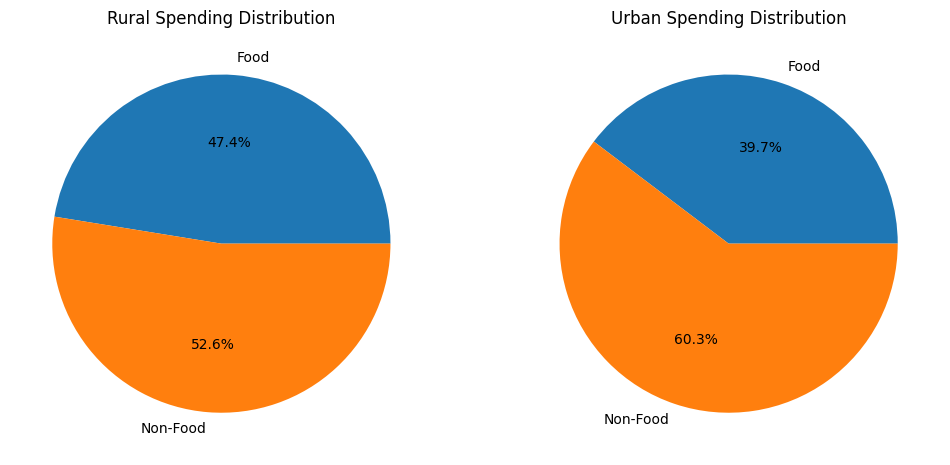

In [67]:
import matplotlib.pyplot as plt

rural_food = rural_india['food_total'].values[0]
rural_nonfood = rural_india['nonfood_total'].values[0]
urban_food = urban_india['food_total'].values[0]
urban_nonfood = urban_india['nonfood_total'].values[0]
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))
# Rural pie chart
axes[0].pie(
    [rural_food, rural_nonfood],
    labels=['Food', 'Non-Food'],
    autopct='%1.1f%%')
axes[0].set_title("Rural Spending Distribution")
# Urban pie chart
axes[1].pie(
    [urban_food, urban_nonfood],
    labels=['Food', 'Non-Food'],
    autopct='%1.1f%%')
axes[1].set_title("Urban Spending Distribution")
plt.show()

**Insight:**
- Rural households allocate a larger share of expenditure to food, indicating a focus on basic necessities
- Urban households spend relatively more on non-food items, reflecting higher disposable income and access to services
- This difference highlights the variation in economic flexibility and lifestyle between rural and urban populations

## Percentage-Based Spending Analysis

* Using:
    - df_percent_rural
    - df_percent_urban
* We analyze:
    - How income is distributed (%)

In [69]:
df_percent_rural.columns = df_percent_rural.columns.str.strip().str.lower()
df_percent_urban.columns = df_percent_urban.columns.str.strip().str.lower()

In [70]:
rural_pct = df_percent_rural[df_percent_rural['state/ut'] == 'All-India']
urban_pct = df_percent_urban[df_percent_urban['state'] == 'All-India']

In [71]:
rural_pct

,state/ut,cereal,cereal substitutes,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
36,All-India,4.97,0.02,0.26,1.78,0.78,0.11,8.44,6.03,2.66,...,7.59,5.25,1.02,0.56,0.21,5.67,0.96,6.48,52.96,100


In [72]:
urban_pct

,state,cereal,cereal substitutes,gram,pulses and pulse products*,sugar,salt,milk and milk products,vegetables,fruits (fresh),...,conveyance,consumer services excluding conveyance&,entertainment,rent,other taxes & cesses,clothing & bedding$,footwear,durable goods,non-food: total (16-30),total expenditure (15+31)
36,All-India,3.74,0.02,0.18,1.22,0.5,0.07,7.19,4.12,2.61,...,8.46,5.72,1.77,6.58,0.33,4.8,0.86,6.87,60.32,100


### Selecting Key Percentage Categories

In [73]:
rural_summary = {
    'Food': rural_pct['food: total (1-14)'].values[0],
    'Non-Food': rural_pct['non-food: total (16-30)'].values[0],
    'Education': rural_pct['education'].values[0],
    'Health': rural_pct['medical (hospitalization)'].values[0] + rural_pct['medical (non- hospitalization)'].values[0],
    'Conveyance': rural_pct['conveyance'].values[0],
    'Services': rural_pct['consumer services excluding conveyance&'].values[0]
}

In [74]:

urban_summary = {
    'Food': urban_pct['food: total (1-14)'].values[0],
    'Non-Food': urban_pct['non-food: total (16-30)'].values[0],
    'Education': urban_pct['education'].values[0],
    'Health': urban_pct['medical (hospitalization)'].values[0] + urban_pct['medical (non- hospitalization)'].values[0],
    'Conveyance': urban_pct['conveyance'].values[0],
    'Services': urban_pct['consumer services excluding conveyance&'].values[0]
}

In [75]:
comparison_pct = pd.DataFrame({
    'Category': list(rural_summary.keys()),
    'Rural (%)': list(rural_summary.values()),
    'Urban (%)': list(urban_summary.values())
})
comparison_pct

,Category,Rural (%),Urban (%)
0,Food,47.04,39.68
1,Non-Food,52.96,60.32
2,Education,3.24,5.97
3,Health,6.83,5.85
4,Conveyance,7.59,8.46
5,Services,5.25,5.72


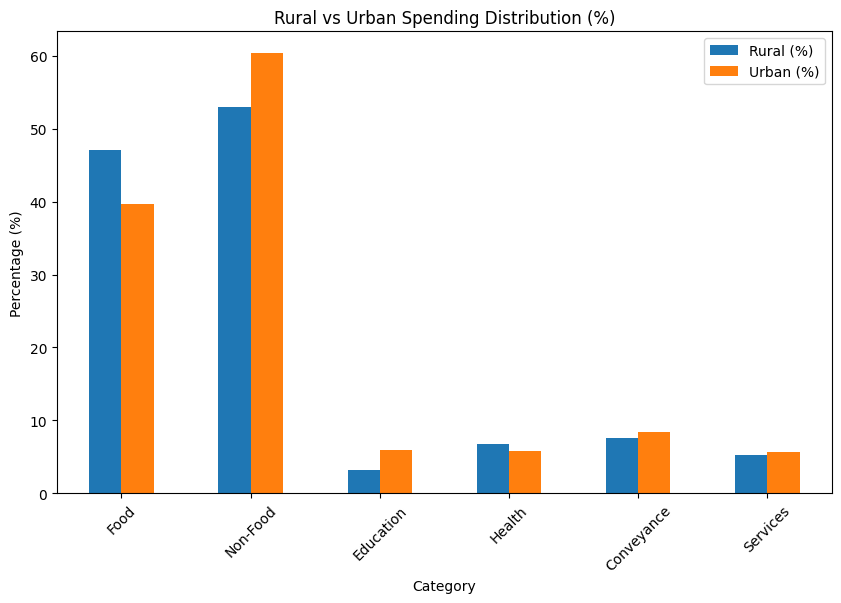

In [76]:
comparison_pct.set_index('Category').plot(kind='bar', figsize=(10,6))
plt.title("Rural vs Urban Spending Distribution (%)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

**Key Insights:**

- Rural households spend a significantly higher percentage on food, indicating dependence on essential consumption
- Urban households allocate a greater share to non-food categories, reflecting higher economic flexibility
- Spending on education and services is higher in urban areas, suggesting better access to infrastructure and opportunities
- Healthcare expenditure is present in both sectors, but urban households tend to allocate slightly more towards it
- The shift from food to non-food expenditure is a strong indicator of economic development and improved living standards